# URL-Phish phishing link classifier

Data from https://data.mendeley.com/datasets/65z9twcx3r/1. Includes 100,000 benign samples and 11,660 phishing samples. 

In [9]:
import pandas as pd

df = pd.read_csv("../data/Dataset.csv")

df.head()

,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  str    
 1   url_len       116600 non-null  int64  
 2   dom           116600 non-null  str    
 3   dom_len       116600 non-null  int64  
 4   is_ip         116600 non-null  int64  
 5   tld           116586 non-null  str    
 6   tld_len       116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  116600 non-null  float64
 18  digit_ratio   1

In [14]:
# Drop all features except url and label, rename label and swap label meaning
df = df[["url", "label"]]
df = df.rename(columns={"label" : "isLegit"})
df["isLegit"] = 1 - df["isLegit"]

df["isLegit"].value_counts()

isLegit
1    100000
0     16600
Name: count, dtype: int64

## Extract features

I modified features.py to include top level domains and instead of "has_params" I added "query_length"-

In [19]:
import sys
sys.path.insert(0, "../src")
import importlib                                                                                                                                                             
import features 

importlib.reload(features)

<module 'features' from '/Users/lassihirvonen/git/Phishing-link-classifier/notebook/../src/features.py'>

In [20]:
# extract features into a datarframe
details = [features.extract_features(url) for url in df["url"]]
df_features = pd.DataFrame(details)
df_features.shape

(116600, 10)

In [21]:
df_features.head()

,is_HTTPS,is_IP,host_length,number_count,dot_count,hyphen_count,path_depth,query_length,tld,entropy
0,1,0,15,0,3,0,1,0,au,3.139572
1,0,0,18,0,3,0,1,0,au,3.308271
2,1,0,14,0,3,0,1,0,au,2.788450
3,0,0,11,0,2,0,1,0,au,2.913977
4,0,0,14,0,3,0,1,0,au,2.788450


In [ ]:
# Combine dataframes
df = pd.concat([df, df_features], axis=1)

In [23]:
df.head()

,url,isLegit,is_HTTPS,is_IP,host_length,number_count,dot_count,hyphen_count,path_depth,query_length,tld,entropy
0,https://www.rmit.edu.au/,1,1,0,15,0,3,0,1,0,au,3.139572
1,http://www.latrobe.edu.au/,1,0,0,18,0,3,0,1,0,au,3.308271
2,https://www.cqu.edu.au/,1,1,0,14,0,3,0,1,0,au,2.788450
3,http://bond.edu.au/,1,0,0,11,0,2,0,1,0,au,2.913977
4,http://www.csu.edu.au/,1,0,0,14,0,3,0,1,0,au,2.788450


## Analyzing dataframe

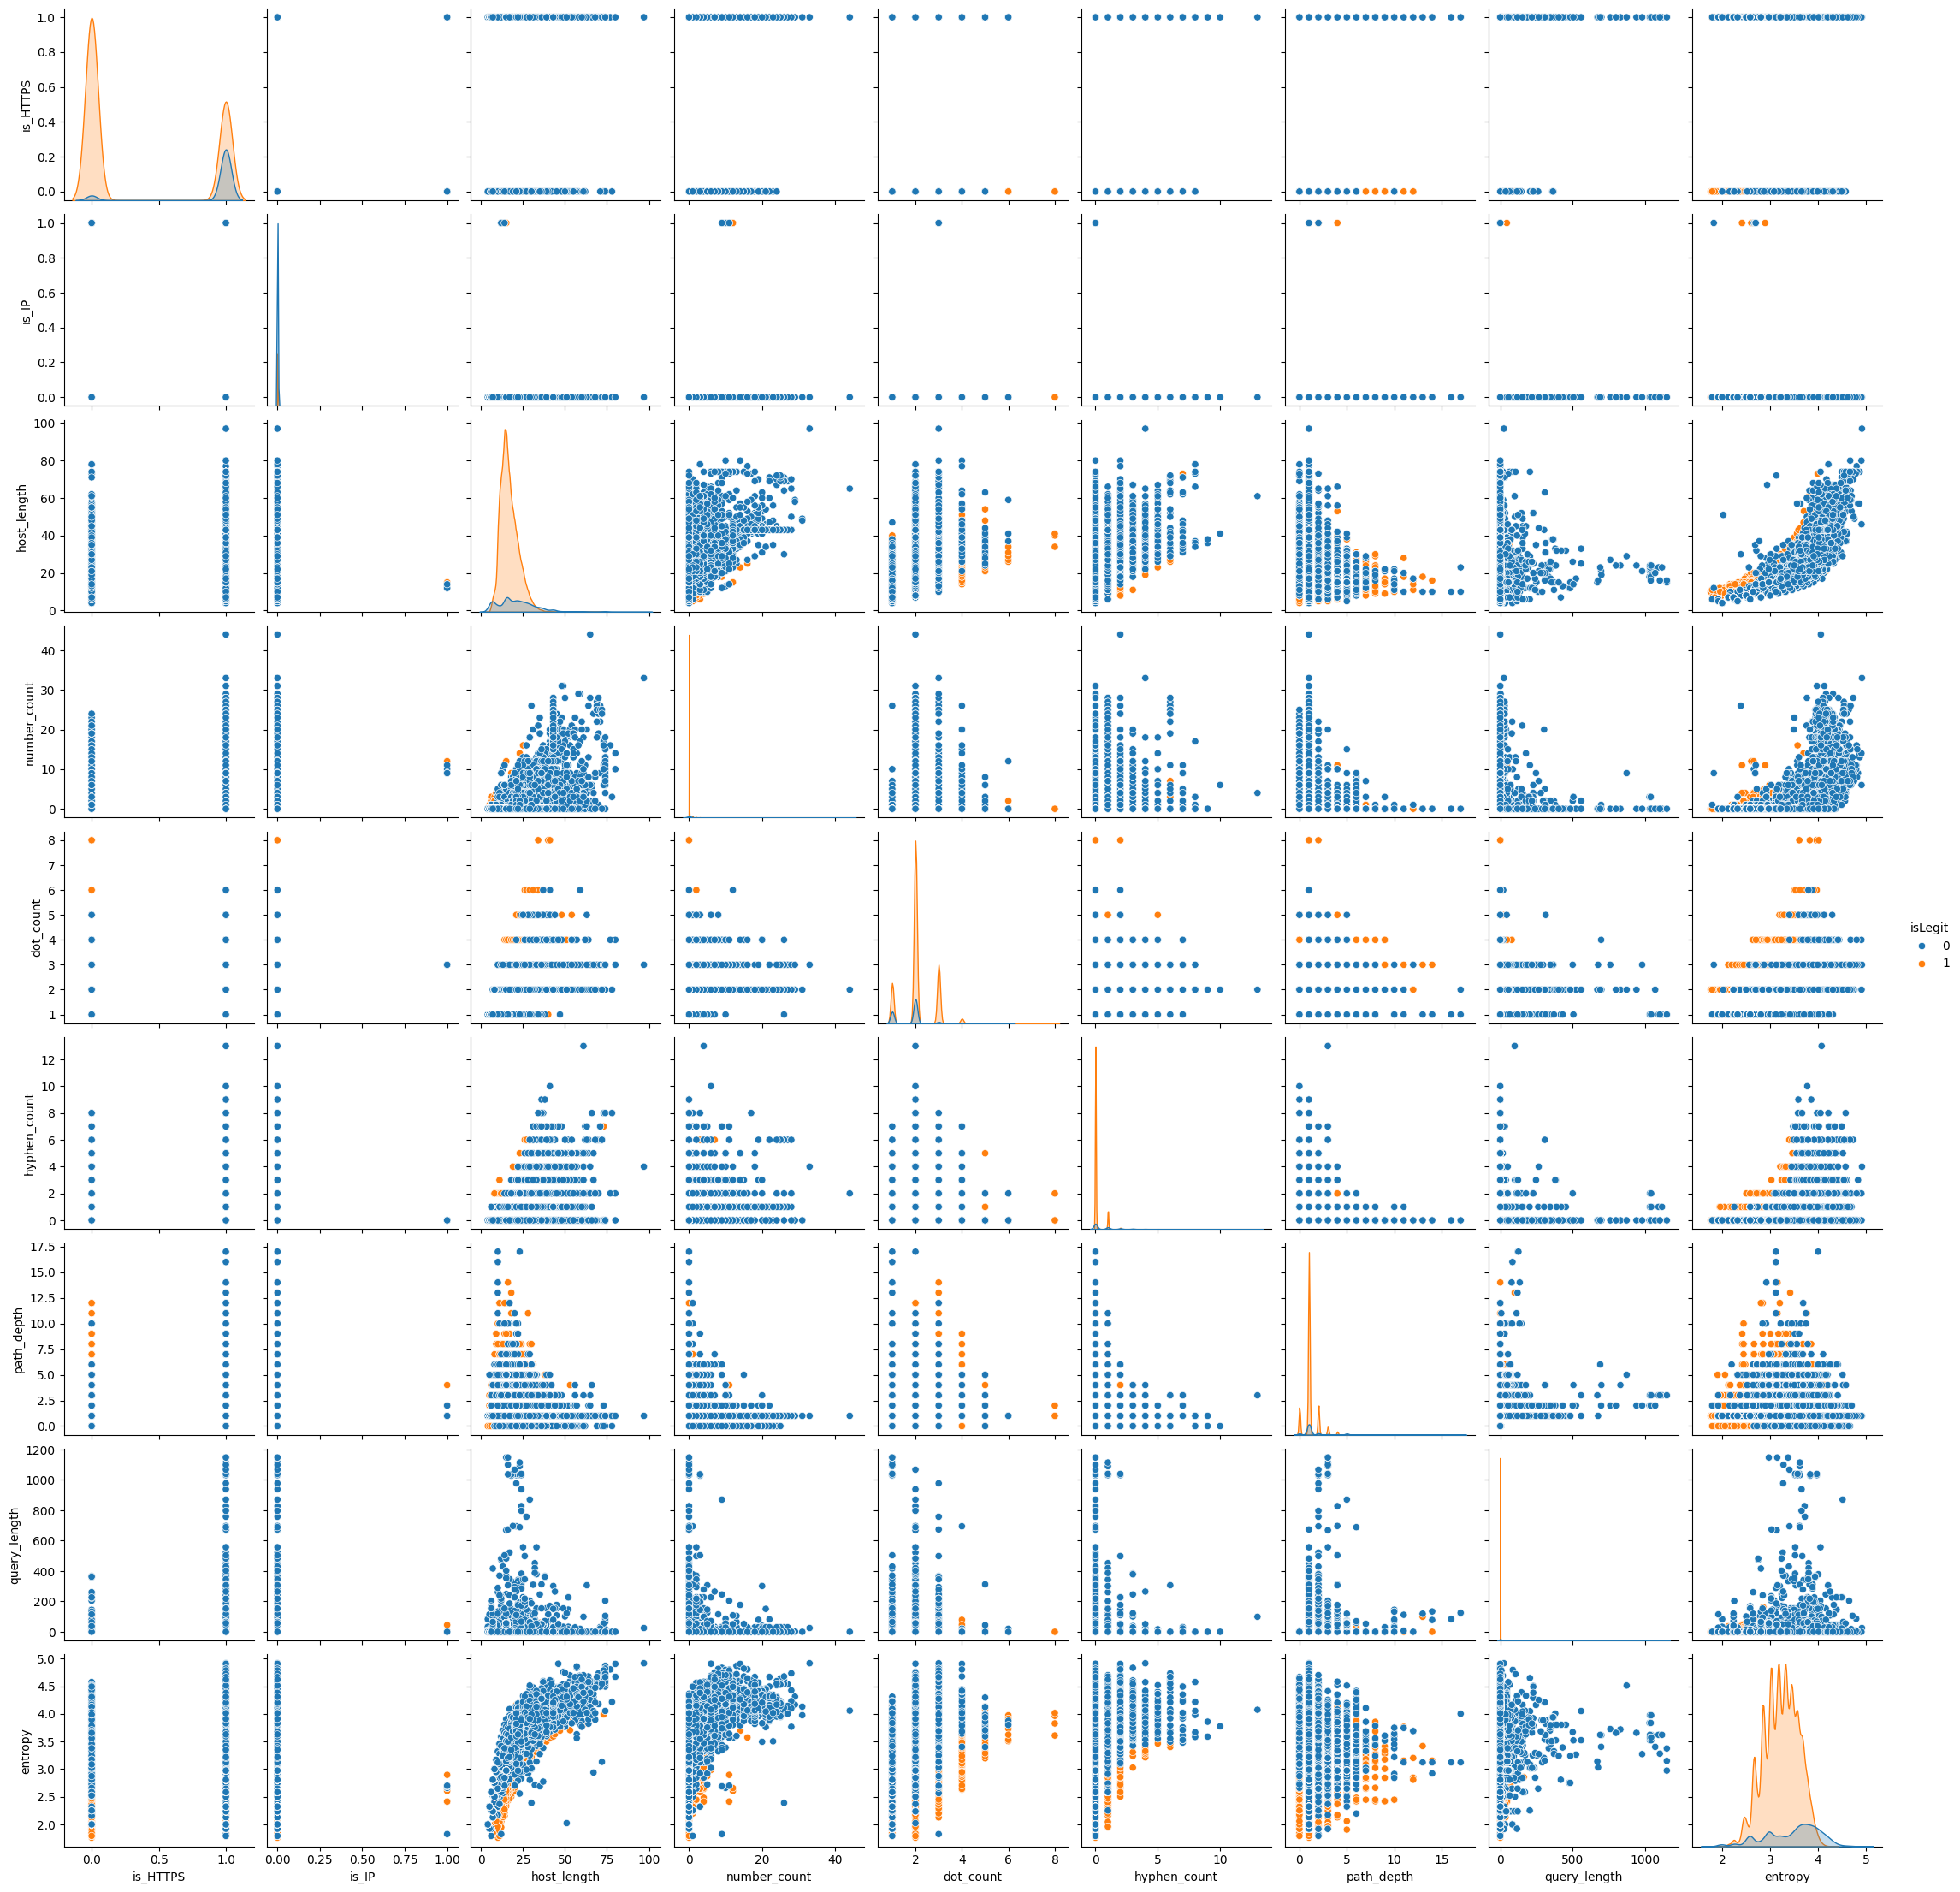

In [24]:
import seaborn as sns

sns.pairplot(df, kind="scatter", hue="isLegit")

## Splitting to training and testing data

In [26]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=["isLegit", "url"])
y = df["isLegit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=55, train_size=0.8)

print(X_train.shape, X_test.shape)

(93280, 10) (23320, 10)


In [28]:
# Encoding tld

X_train = pd.get_dummies(X_train, columns=["tld"])
X_test = pd.get_dummies(X_test, columns=["tld"]).reindex(columns=X_train.columns, fill_value=0)

## Training models

In [29]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(max_depth=5, random_state=2).fit(X_train, y_train)

In [30]:
print(f"Training data: {model_tree.score(X_train, y_train)}")
print(f"Testing data: {model_tree.score(X_test, y_test)}")

Training data: 0.9276586620926244
Testing data: 0.9297169811320755


In [31]:
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(max_depth=None, random_state=2).fit(X_train, y_train)

In [32]:
print(f"Training data: {model_forest.score(X_train, y_train)}")
print(f"Testing data: {model_forest.score(X_test, y_test)}")

Training data: 0.9880145797598627
Testing data: 0.9719554030874785


In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

model_gb = gb.fit(X_train, y_train)

In [34]:
print(f"Training data: {model_gb.score(X_train, y_train)}")
print(f"Testing data: {model_gb.score(X_test, y_test)}")

Training data: 0.9539129502572898
Testing data: 0.9548027444253859


## Benchmark models with confusion matrix

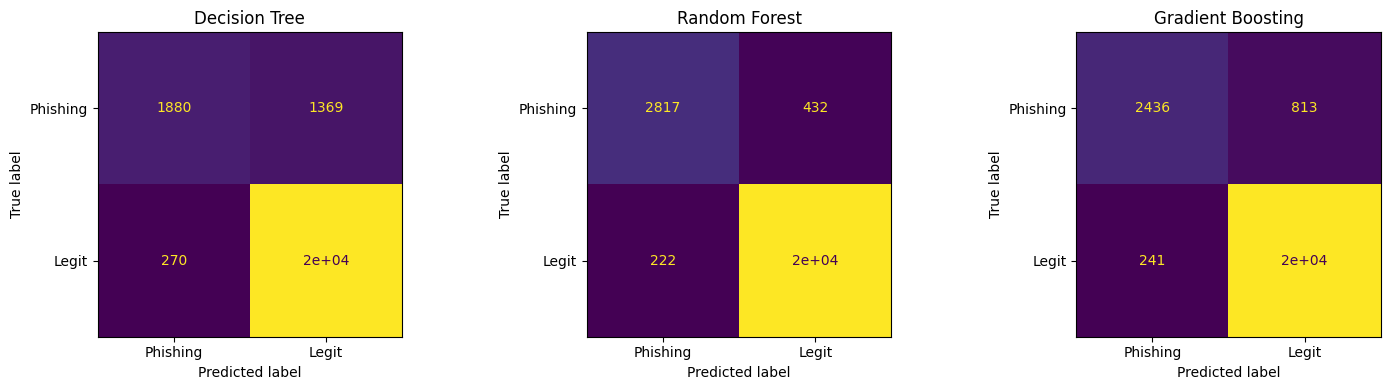

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = [
    ("Decision Tree", model_tree),
    ("Random Forest", model_forest),
    ("Gradient Boosting", model_gb),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Phishing", "Legit"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

Out of the three models Random forest scores best detecting phishing and legit sites.

## Testing models with custom links

In [37]:
custom_urls = [
    "https://www.google.com",
    "http://192.168.1.1/login?user=admin",
    "https://paypal-secure-login.xyz/verify",
    "https://lassihirvonen.com/palvelinten_hallinta/",
    "https://m1crosoft.com"
]

df_custom = pd.DataFrame({"URL": custom_urls})
df_custom = pd.concat(
    [df_custom, pd.DataFrame([features.extract_features(url) for url in custom_urls])],
    axis=1,
)

X_custom = df_custom.drop(columns=["URL"])
X_custom = pd.get_dummies(X_custom, columns=["tld"])
X_custom = X_custom.reindex(columns=X_train.columns, fill_value=0)

print(f"Decision tree: {model_tree.predict(X_custom)}")
print(f"Random forest: {model_forest.predict(X_custom)}")
print(f"Gradient boosting: {model_gb.predict(X_custom)}")

Decision tree: [1 1 0 1 1]
Random forest: [1 0 0 0 1]
Gradient boosting: [1 1 0 0 1]


## Exporting current models

In [38]:
import joblib

joblib.dump(model_tree, "../models/URL-Phish_model_tree.pkl")
joblib.dump(model_forest, "../models/URL-Phish_model_forest.pkl")
joblib.dump(model_gb, "../models/URL-Phish_model_gb.pkl")

['../models/URL-Phish_model_gb.pkl']